In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("C:\\Users\\jsand\\OneDrive - OsloMet\\NETTSKY\\JOBB\\IT\\prosjekter\\Microsoft-ML-Course\\Clustering\\Data\\nigerian-songs.csv")

Text(0.5, 1.0, 'Top genres')

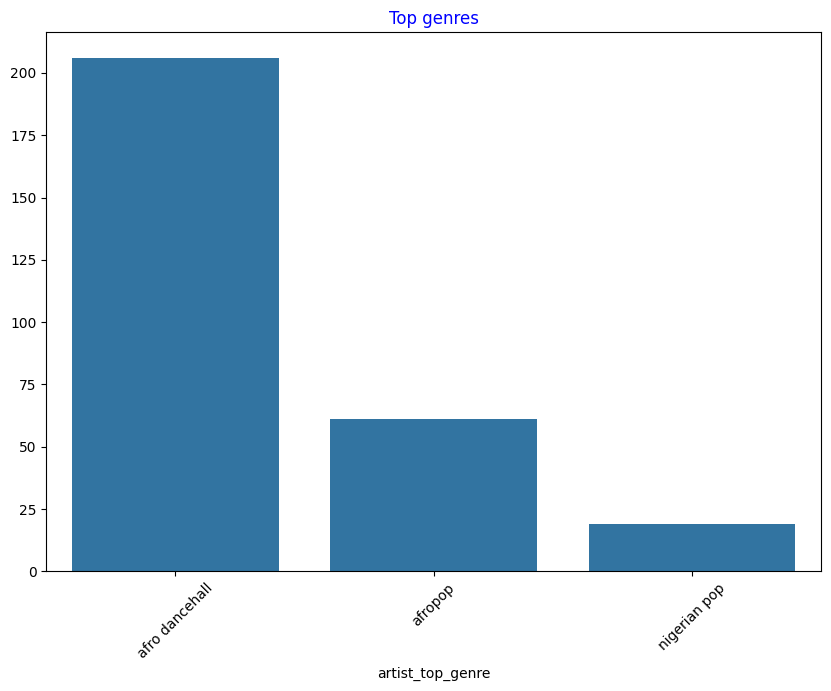

In [2]:
df = df[(df['artist_top_genre'] == 'afro dancehall') | (df['artist_top_genre'] == 'afropop') | (df['artist_top_genre'] == 'nigerian pop')]
df = df[(df['popularity'] > 0)]
top = df['artist_top_genre'].value_counts()
plt.figure(figsize=(10,7))
sns.barplot(x=top.index,y=top.values)
plt.xticks(rotation=45)
plt.title('Top genres',color = 'blue')

<Axes: xlabel='release_date'>

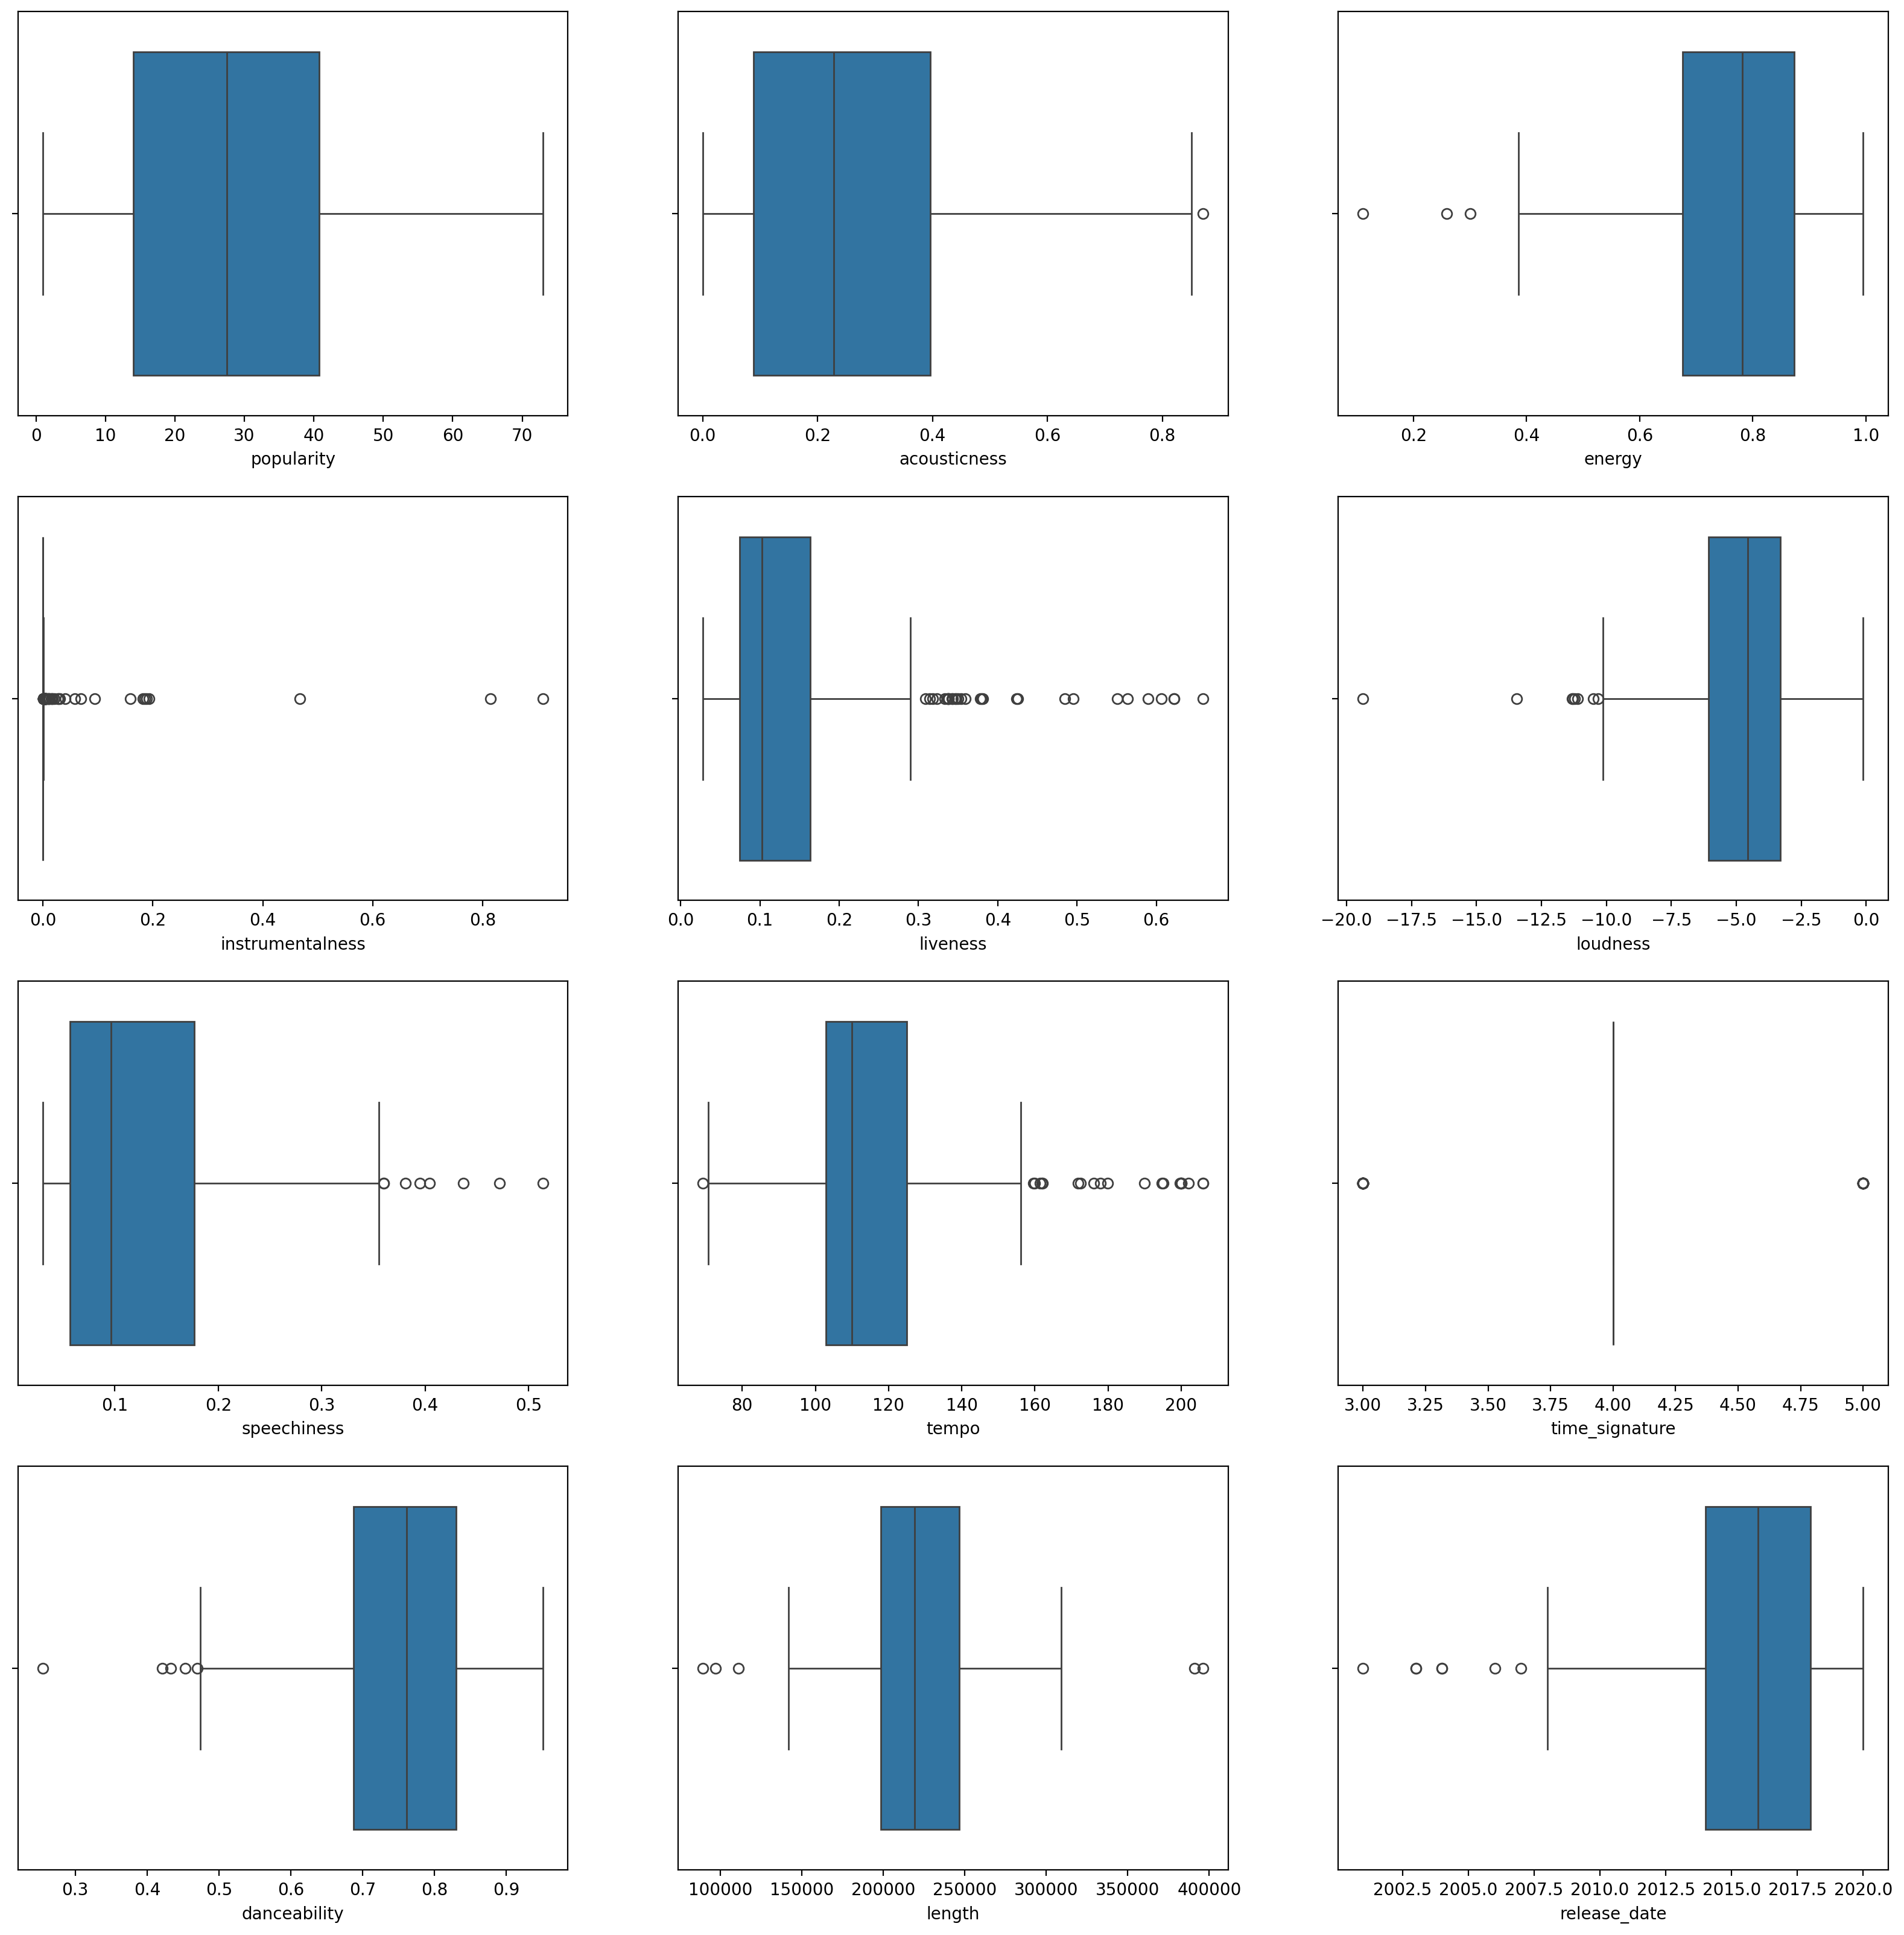

In [3]:
plt.figure(figsize=(20,20), dpi=200)

plt.subplot(4,3,1)
sns.boxplot(x = 'popularity', data = df)

plt.subplot(4,3,2)
sns.boxplot(x = 'acousticness', data = df)

plt.subplot(4,3,3)
sns.boxplot(x = 'energy', data = df)

plt.subplot(4,3,4)
sns.boxplot(x = 'instrumentalness', data = df)

plt.subplot(4,3,5)
sns.boxplot(x = 'liveness', data = df)

plt.subplot(4,3,6)
sns.boxplot(x = 'loudness', data = df)

plt.subplot(4,3,7)
sns.boxplot(x = 'speechiness', data = df)

plt.subplot(4,3,8)
sns.boxplot(x = 'tempo', data = df)

plt.subplot(4,3,9)
sns.boxplot(x = 'time_signature', data = df)

plt.subplot(4,3,10)
sns.boxplot(x = 'danceability', data = df)

plt.subplot(4,3,11)
sns.boxplot(x = 'length', data = df)

plt.subplot(4,3,12)
sns.boxplot(x = 'release_date', data = df)

In [50]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

# ---- Select features ----
X = df.loc[:, ('artist_top_genre','popularity','danceability','acousticness','loudness','energy')]

# ---- FIX: One-hot encode genre ----
X = pd.get_dummies(X, columns=['artist_top_genre'])

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---- Test different k values ----
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=0, n_init=20, max_iter=500)
    labels = km.fit_predict(X_scaled)
    score = metrics.silhouette_score(X_scaled, labels)
    print("k =", k, "score =", score)

k = 2 score = 0.3450050915845667
k = 3 score = 0.37378385878900144
k = 4 score = 0.2573642908248575
k = 5 score = 0.24804974690701412
k = 6 score = 0.2440265027859752
k = 7 score = 0.23716835581422688
k = 8 score = 0.22825854892670125
k = 9 score = 0.23375199298084673


In [ ]:
from sklearn.cluster import KMeans
# ---- Final model ----
nclusters = 3   # best from your earlier results
seed = 0

km = KMeans(n_clusters=nclusters, random_state=seed, n_init=20, max_iter=500)
y_cluster_kmeans = km.fit_predict(X_scaled)

# ---- Silhouette score ----
score = metrics.silhouette_score(X_scaled, y_cluster_kmeans)
print("Final silhouette score:", score)

Final silhouette score: 0.37378385878900144


In [53]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=20)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


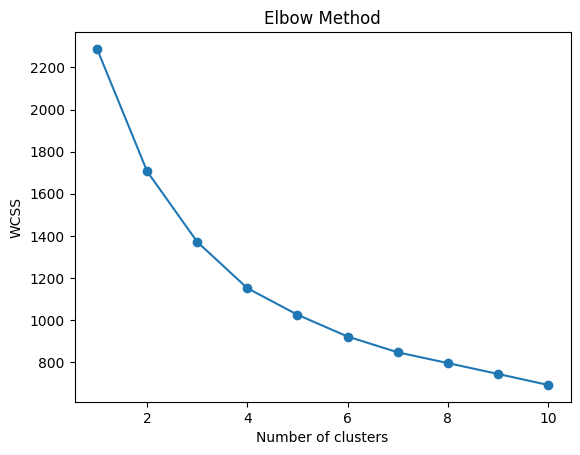

In [54]:
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

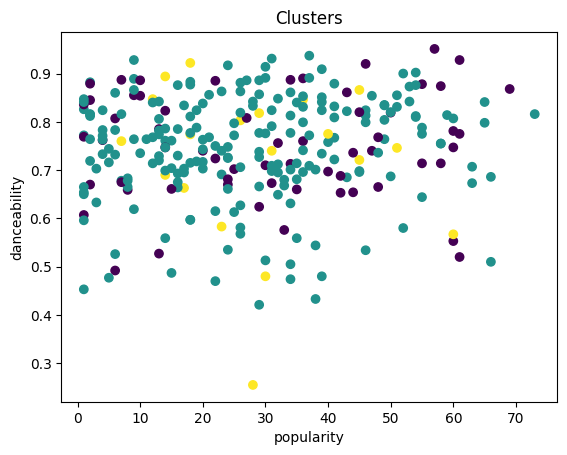

In [55]:
# ---- Scatter plot (same as before) ----
kmeans = KMeans(n_clusters=nclusters, n_init=20, random_state=42)
labels = kmeans.fit_predict(X_scaled)

plt.scatter(df['popularity'], df['danceability'], c=labels)
plt.xlabel('popularity')
plt.ylabel('danceability')
plt.title('Clusters')
plt.show()